<a href="https://colab.research.google.com/github/debojeet01/Satellite-image-classification/blob/main/Satellite_image_classifiction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from zipfile import ZipFile

In [3]:
with ZipFile('/content/drive/MyDrive/archive.zip','r') as zipobj:
  zipobj.extractall('/content/dataset')

In [4]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from PIL import Image
from tensorflow.keras import layers, models

In [6]:
dataset_path = "/content/dataset/data"

class_names = ["cloudy", "desert", "green_area", "water"]

image_paths = []
labels = []

for label, class_name in enumerate(class_names):

    class_folder = os.path.join(dataset_path, class_name)

    for file_name in os.listdir(class_folder):

        if file_name.lower().endswith((".jpg", ".jpeg", ".png")):

            image_paths.append(
                os.path.join(class_folder, file_name)
            )

            labels.append(label)

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Total images:", len(image_paths))

Total images: 5609


In [7]:
rng = np.random.default_rng(123)

indices = np.arange(len(image_paths))
rng.shuffle(indices)

image_paths = image_paths[indices]
labels = labels[indices]

split_index = int(0.8 * len(image_paths))

train_paths = image_paths[:split_index]
train_labels = labels[:split_index]

validation_paths = image_paths[split_index:]
validation_labels = labels[split_index:]

print("Training images:", len(train_paths))
print("Validation images:", len(validation_paths))

Training images: 4487
Validation images: 1122


In [8]:
class PILDataGenerator(tf.keras.utils.Sequence):

    def __init__(self, paths, labels, batch_size=32, shuffle=False):
        self.paths = paths
        self.labels = labels
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.indices = np.arange(len(self.paths))

        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.paths) / self.batch_size))

    def __getitem__(self, index):

        batch_indices = self.indices[
            index * self.batch_size:
            (index + 1) * self.batch_size
        ]

        batch_images = []
        batch_labels = []

        for i in batch_indices:

            img = Image.open(self.paths[i]).convert("RGB")

            img = img.resize((224, 224))

            img = np.asarray(img, dtype=np.float32)

            batch_images.append(img)
            batch_labels.append(self.labels[i])

        return (
            np.array(batch_images, dtype=np.float32),
            np.array(batch_labels, dtype=np.int64)
        )

    def on_epoch_end(self):

        if self.shuffle:
            np.random.shuffle(self.indices)

In [9]:
corrected_train_dataset = PILDataGenerator(
    train_paths,
    train_labels,
    batch_size=32,
    shuffle=True
)

corrected_validation_dataset = PILDataGenerator(
    validation_paths,
    validation_labels,
    batch_size=32,
    shuffle=False
)

print("Corrected datasets ready!")

Corrected datasets ready!


In [10]:
images, labels = corrected_validation_dataset[0]

print("Batch shape:", images.shape)

for i in range(8):
    print(
        f"Image {i+1}: "
        f"min={images[i].min():.0f}, "
        f"max={images[i].max():.0f}, "
        f"class={class_names[labels[i]]}"
    )

Batch shape: (32, 224, 224, 3)
Image 1: min=30, max=132, class=green_area
Image 2: min=21, max=72, class=water
Image 3: min=132, max=201, class=desert
Image 4: min=36, max=82, class=water
Image 5: min=32, max=116, class=green_area
Image 6: min=91, max=225, class=desert
Image 7: min=24, max=105, class=green_area
Image 8: min=157, max=191, class=cloudy


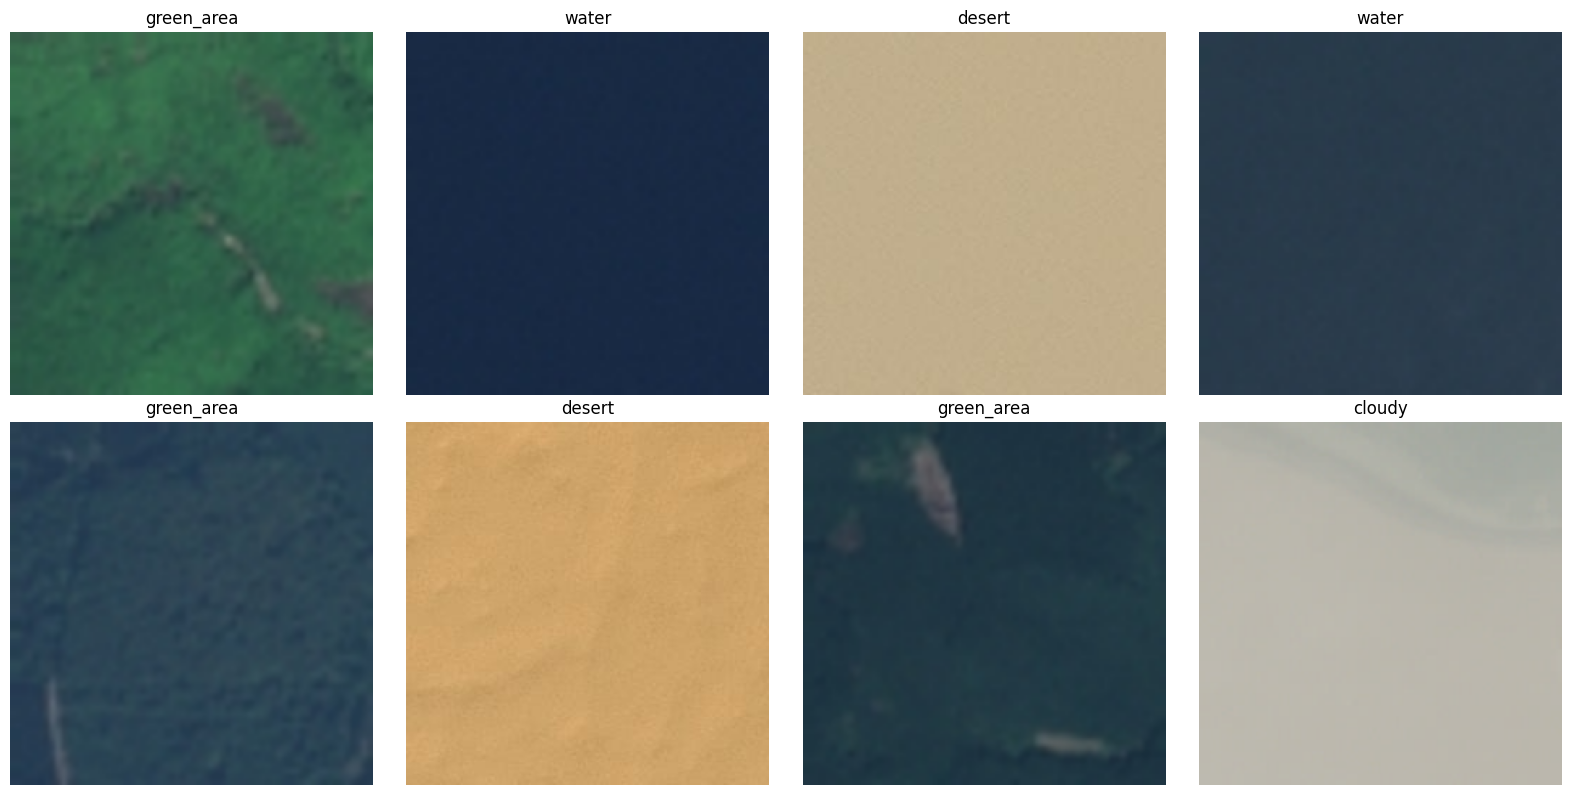

In [11]:
plt.figure(figsize=(16, 8))

for i in range(8):

    plt.subplot(2, 4, i + 1)

    plt.imshow(images[i].astype(np.uint8))

    plt.axis("off")
    plt.title(class_names[labels[i]])

plt.tight_layout()
plt.show()

In [12]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model_corrected = models.Sequential([

   #rescaling
    layers.Rescaling(
        scale=1/127.5,
        offset=-1
    ),

  #mobilenetv2
   base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(4, activation="softmax")
])

model_corrected.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_corrected.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history_corrected = model_corrected.fit(
    corrected_train_dataset,
    validation_data=corrected_validation_dataset,
    epochs=10
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


141/141 ━━━━━━━━━━━━━━━━━━━━ 256s 2s/step - accuracy: 0.9485 - loss: 0.1599 - val_accuracy: 0.9857 - val_loss: 0.0432
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 248s 2s/step - accuracy: 0.9819 - loss: 0.0502 - val_accuracy: 0.9911 - val_loss: 0.0240
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 249s 2s/step - accuracy: 0.9877 - loss: 0.0376 - val_accuracy: 0.9920 - val_loss: 0.0184
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 264s 2s/step - accuracy: 0.9922 - loss: 0.0277 - val_accuracy: 0.9902 - val_loss: 0.0210
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 268s 2s/step - accuracy: 0.9926 - loss: 0.0225 - val_accuracy: 0.9929 - val_loss: 0.0194
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 265s 2s/step - accuracy: 0.9949 - loss: 0.0174 - val_accuracy: 0.9938 - val_loss: 0.0158
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 340s 2s/step - accuracy: 0.9949 - loss: 0.0175 - val_accuracy: 0.9920 - val_loss: 0.0159
Epoch 8/10
130/141 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.9962 - loss: 0.0109

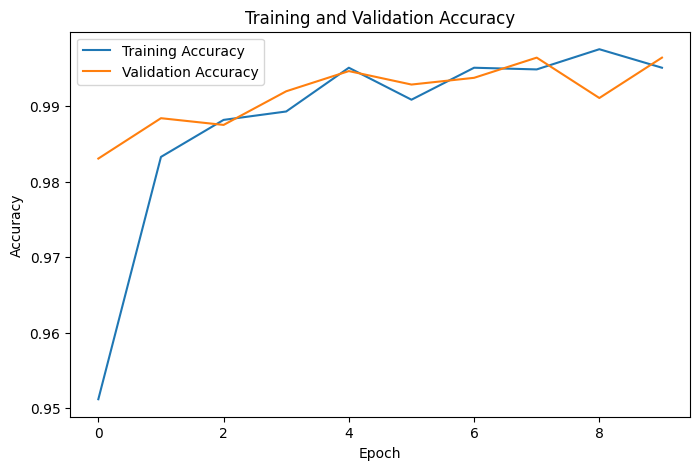

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_corrected.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_corrected.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

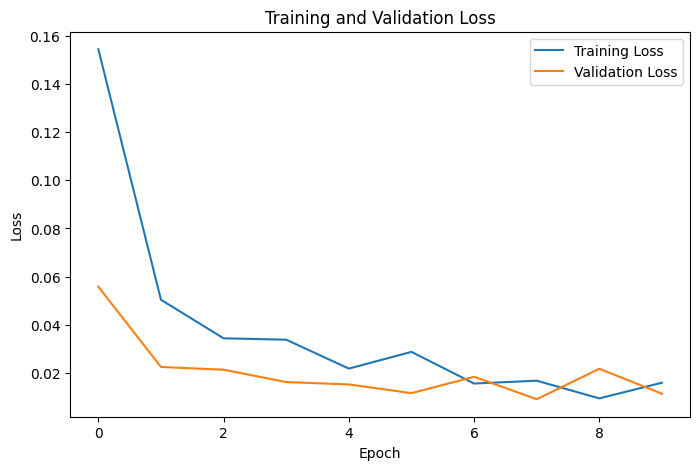

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_corrected.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_corrected.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [ ]:
loss, accuracy = model_corrected.evaluate(
    corrected_validation_dataset,
    verbose=1
)

print("Corrected Validation Accuracy:", accuracy)
print("Corrected Validation Loss:", loss)

36/36 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.9964 - loss: 0.0113
Corrected Validation Accuracy: 0.9964349269866943
Corrected Validation Loss: 0.0113311056047678


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report  #evlntn mtrix

In [ ]:
y_true = []
y_pred = []

for i in range(len(corrected_validation_dataset)):

    images, labels = corrected_validation_dataset[i]

    predictions = model_corrected.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels)
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      cloudy       1.00      1.00      1.00       272
      desert       1.00      1.00      1.00       237
  green_area       1.00      0.99      0.99       299
       water       0.99      1.00      0.99       314

    accuracy                           1.00      1122
   macro avg       1.00      1.00      1.00      1122
weighted avg       1.00      1.00      1.00      1122



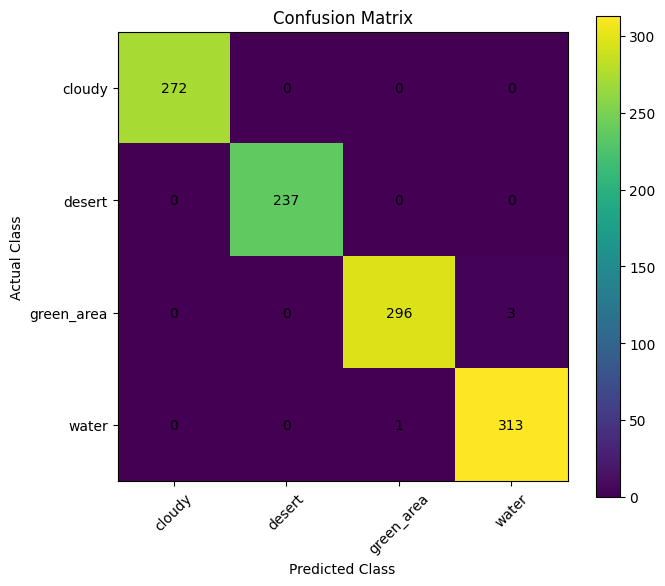

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")

plt.colorbar()

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [ ]:
model_corrected.save(
    "satellite_classifier_corrected.keras"
)

print("Corrected model saved successfully!")

Corrected model saved successfully!


In [ ]:
from tensorflow.keras.models import load_model

model_corrected = load_model(
    "satellite_classifier_corrected.keras"
)

print("Corrected model loaded successfully!")

Corrected model loaded successfully!


In [ ]:
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

img = load_img(
    image_path,
    target_size=(224, 224)
)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

img_array = img_to_array(img).astype(np.float32)




img_array = np.expand_dims(img_array, axis=0)

prediction = model_corrected.predict(
    img_array,
    verbose=0
)

predicted_index = np.argmax(prediction[0])

predicted_class = class_names[predicted_index]

confidence = prediction[0][predicted_index] * 100

print("================================")
print("SATELLITE IMAGE CLASSIFICATION")
print("================================")

print("Predicted Class:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

print("\nClass Probabilities:")

for i, class_name in enumerate(class_names):

    print(
        f"{class_name}: "
        f"{prediction[0][i] * 100:.2f}%"
    )